In [1]:
import gsw
import numpy as np

# QA for Metabolic Index

Most of this file consists of QA on the pO2 and DO_sat calculations. Other files were reviewed with small comments left separately:

 * 2b_DO_Saturation_ForMinMetabolic_MinDOrun_vs3_MeanMaxMinDO.ipynb
 * 3c_Metabolic_MinMaxMetabolic_Salmon_All_basal_routine_andCIs.ipynb

## Test pO2 calculation method against given concentrations and equivalent pO2's at varying depths

[Ultsch, 2019](https://doi.org/10.1016/j.cbpa.2019.05.007) provides a table of DO saturation points at varying temperatures as both concentrations in mg/L and as equivalent partial pressures. Extra precision on the DO concentrations is avialable by going back to the original source for them, Mortimer 1981. This can be used as an independent validation of the pO2 calculations in [2b_DO_Saturation_ForMinMetabolic_MinDOrun_vs3_MeanMaxMinDO.ipynb](2b_DO_Saturation_ForMinMetabolic_MinDOrun_vs3_MeanMaxMinDO.ipynb).

First initialize the data structures with the test data. In addition to the data from the table, the calculation is repeated using a range of depths from the surface (which should closely match Ultsch/Mortimer's numbers) to 200 meters, approximating the range of depths in Puget Sound. This will show the possible effect of depth on any errors found.

In [2]:
# Test cases from Ultsch 2019 Table 1. All represent saturation conditions at
# different in-situ temperatures. Extra precision added to saturated DO
# concentrations from their source: Mortimer 1981, Appendix 1.
T =  np.array([   0,    5,   10,   15,   20,   25])
DO =  np.array([14.6211, 12.7699, 11.2876, 10.0837,  9.0920,  8.2628])
PO2 = np.array([21.1, 21.0, 20.9, 20.8, 20.7, 20.5])

Z = np.array([0, -20, -30, -50, -80, -100, -200])

# The numbers given are clearly for fresh water
s = 0

# Let's just pick the Puget Sound region for lat/lon. I don't think it will matter.
lat = 48
lon = -122

Compute pressure for each height

In [3]:
P = gsw.p_from_z(Z, lat)
P

array([ -0.        ,  20.17020803,  30.25605272,  50.42922304,
        80.69267969, 100.87078393, 201.79087861])

This closely follows the computation in [2b_DO_Saturation_ForMinMetabolic_MinDOrun_vs3_MinMaxMeanDO.ipynb](2b_DO_Saturation_ForMinMetabolic_MinDOrun_vs3_MinMaxMeanDO.ipynb)

In [4]:
do_sat = np.zeros((len(P), len(T)))
for i,p in enumerate(P):
    CT = gsw.CT_from_t(s, T, p)  # Conservative temperature calculation using GSW function See: https://www.teos-10.org/pubs/gsw/html/gsw_CT_from_t.html
    density_est_kg_m3 = gsw.rho_t_exact(s, CT, p)  # Calculate in-situ density using GSW function
    solubility_GSW_output = gsw.O2sol(s, CT, p, lon, lat) # solubility in μmol/kg
    do_sat[i] = (solubility_GSW_output * 31.998 / 1000) * (density_est_kg_m3 / 1000)
do_sat - DO

array([[-1.10370213e-04, -4.44506586e-04, -1.22277250e-03,
        -2.05351846e-03, -2.90402281e-03, -3.61115858e-03],
       [ 1.02488281e-03,  8.91264808e-04,  1.82075009e-04,
        -6.49454018e-04, -1.53581337e-03, -2.29395079e-03],
       [ 1.59384322e-03,  1.56000500e-03,  8.85056602e-04,
         5.29470174e-05, -8.51464014e-04, -1.63518643e-03],
       [ 2.73442947e-03,  2.89919329e-03,  2.29213504e-03,
         1.45848661e-03,  5.17724041e-04, -3.17336647e-04],
       [ 4.45196528e-03,  4.91224231e-03,  4.40553958e-03,
         3.56863953e-03,  2.57272963e-03,  1.66024109e-03],
       [ 5.60142128e-03,  6.25711687e-03,  5.81633288e-03,
         4.97663691e-03,  3.94354917e-03,  2.97916193e-03],
       [ 1.14017451e-02,  1.30155282e-02,  1.28925572e-02,
         1.20313630e-02,  1.08074398e-02,  9.58020216e-03]])

Above is the absolute error in DO saturation, all quite small. Each row of this data contains values for a single depth at increasing temperature, with surface in the first row and 200 meters at the bottom row. The surface values are most important for validating the calculation.

Check our percent error on calculating DO_sat.

In [5]:
(do_sat - DO) / DO * 100

array([[-0.00075487, -0.00348089, -0.01083288, -0.02036473, -0.03194042,
        -0.04370381],
       [ 0.00700961,  0.00697942,  0.00161305, -0.00644063, -0.01689192,
        -0.02776239],
       [ 0.01090098,  0.01221627,  0.00784096,  0.00052508, -0.00936498,
        -0.01978974],
       [ 0.01870194,  0.02270334,  0.02030666,  0.0144638 ,  0.00569428,
        -0.00384055],
       [ 0.03044891,  0.03846735,  0.03902991,  0.03539018,  0.02829663,
         0.02009296],
       [ 0.03831053,  0.04899895,  0.05152852,  0.04935328,  0.04337384,
         0.03605511],
       [ 0.07798145,  0.10192349,  0.11421876,  0.11931496,  0.11886757,
         0.11594377]])

This is a very small difference, so we're reproducing Mortimer's data with GSW pretty accurately. Note that this is not an "error" per se, only a validation that we appear to be computing DO_sat correctly. Mortimer's parameterizations may be a little dated and are not the latest parameterization in use by TEOS, we just expect them to be very close.

A clear trend is present in both the absolute and relative errors where errors get larger with greater depth, but they are not that large (0.12 percent max), showing that any issues with depth accuracy (eg due to bathymmetric smoothing in the model grid or mistakes in the output processing) will not have a meaningful impact on the results. Because of this, there is really no need to closely review how depth information was incorporated into this processing.

Next step is verifying the pO2 calculation. We should be able to get the same values in Ulsch.

Start with Stefano's method.

In [6]:
PO2_calc = DO / do_sat * (101.3253 * 0.2095)
(PO2_calc - PO2) / PO2 * 100

array([[0.6057374 , 1.08756804, 1.57870893, 2.07679896, 2.58180056,
        3.59478877],
       [0.59792643, 1.0769947 , 1.56606671, 2.06258477, 2.56636093,
        3.57826971],
       [0.59401223, 1.0717021 , 1.55974176, 2.05547543, 2.5586401 ,
        3.57001014],
       [0.5861664 , 1.06110504, 1.5470842 , 2.04125225, 2.54319641,
        3.55349092],
       [0.57435417, 1.04517988, 1.52807871, 2.01990627, 2.52002579,
        3.52871192],
       [0.56645042, 1.03454342, 1.51539565, 2.00566815, 2.50457534,
        3.51219246],
       [0.52658588, 0.98112579, 1.451828  , 1.93438832, 2.42728268,
        3.42959373]])

It looks like we're a few percent off, getting worse at higher temperatures. But this shouldn't be surprising; Ultsch gives a varying saturation pO2 with temperature, but the formula we used doesn't account for temperature when calculating saturation pO2 from a given relative saturation. If `DO == do_sat` (and we're quite close), then pO2 would just be 0.2095 atm (21.23 kPa) everywhere. Strangely, Ultsch's numbers are all lower than this value we would expect for a standard atmospheric pO2.

Let's see what's going on.

In [7]:
do_sat

array([[14.62098963, 12.76945549, 11.28637723, 10.08164648,  9.08909598,
         8.25918884],
       [14.62212488, 12.77079126, 11.28778208, 10.08305055,  9.09046419,
         8.26050605],
       [14.62269384, 12.77146   , 11.28848506, 10.08375295,  9.09114854,
         8.26116481],
       [14.62383443, 12.77279919, 11.28989214, 10.08515849,  9.09251772,
         8.26248266],
       [14.62555197, 12.77481224, 11.29200554, 10.08726864,  9.09457273,
         8.26446024],
       [14.62670142, 12.77615712, 11.29341633, 10.08867664,  9.09594355,
         8.26577916],
       [14.63250175, 12.78291553, 11.30049256, 10.09573136,  9.10280744,
         8.2723802 ]])

Maybe the correct pO2 is something we get from Henry's Law.

From Water Chemistry by Mark Benjamin, I have a Henry's constant H_pm for oxygen at 25 degrees C. But watch what happens when we calculate the saturation DO using Henry's Law assuming an atmospheric concentration of O2 (the way we learned in school):

In [8]:
Hpm = 769 # atm/(mol/L)
Po2g = 0.209 # partial pressure of O2 atmosphere (gas phase)

do_sat_naive = Po2g / Hpm * 31.998 * 1000 # convert from mol/L to mg/L

print(f'Henry\'s Law: {do_sat_naive:0.3f};   GSW {do_sat[0,-1]:0.3f}')

Henry's Law: 8.696;   GSW 8.259


We get the wrong answer! Something is happening in the water that makes it unable to hold as much oxygen as we would think. In other words, if we think of the actual aqueous concentration in terms of a partial pressure, that partial pressure would be lower than the atmospheric partial pressure of O2 but would represent the concentration. That's how it appears that we are supposed to calculate pO2.

Here's how we do this for the Henry's constant I have @ 25C.

In [9]:
do_sat[0,-1] / 1000 / 31.998 * Hpm

0.19849103753528674

This is pretty close to the given value in Ultsch. Let's take their saturation concentration and try the same method to see if we get closer to their value.

In [10]:
DO[-1] / 1000 / 31.998 * Hpm

0.1985778236139759

Still not right.

I think what makes the least sense to me right now is that the Henry's Law constant should give the same solubility of oxygen in fresh water at 1 atm pressure and the right temperature that GSW's O2sat gives. But we don't see that. I know GSW is working correctly because its results align with the values from Mortimer 1981. So it's like Henry's Law doesn't actually work, and I don't know why not.

As one final check, let's just look at a fit between absolute temperature and pO2_sat to create an empirical model, assuming Ultsch is correct about their values.

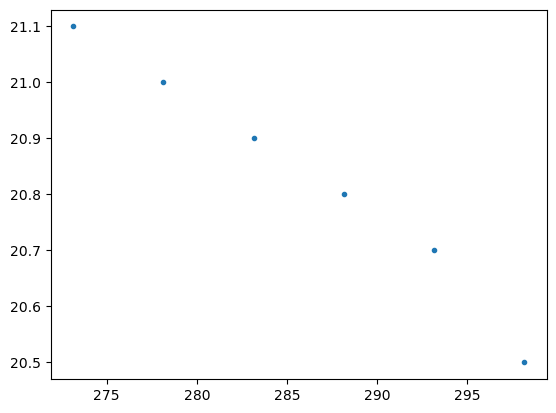

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(T + 273.15, PO2, '.')

In [12]:
import scipy.stats as stats
b0, b1, rval, pval, sb0 = stats.linregress(T + 273.15, PO2)

print(f'pO2_sat [kPa] ~= {b0} T [K] + {b1}')

pO2_sat [kPa] ~= -0.022857142857142902 T [K] + 27.3624761904762


The above empirical fit can be used to get a better approximation of the saturation pO2, which can be multiplied by the DO/DO_sat ratio to get a different estimate of pO2. Then the analysis of areas where pO2 < p_crit can be performed again to see how sensitive it is to this difference.

### Review of Tim Essington's pO2 calculation method

Tim's R script is invoking a function from the library RespR called convert_DO to convert from concentrations to pO2. The code for this function is on Github [here](https://github.com/januarharianto/respR/blob/master/R/convert_DO.R). The function is able to convert to and from many different units, and it does so by first converting whatever was given to mg/L, then converting it to whatever destination unit is desired.

The line of code which converts the intermediate value in mg/L (variable `c`) to a pO2 in kPa is this:

```
if(tou == units.val('kPa',    'o2', msg = "convert_DO")) {out <- c / omWt / oGas * oAtm * (P - vpor) * 1e3 * 101.3253}
```

The formula used here is relatively straightforward. It:

 * divides by the molecular mass `omWt` to convert to a molar concentration
 * divides by the O2 saturation concentration `oGas` just like Stefano's code does
 * multiplies by the atmospheric O2 composition `oAtm` just like Stefano's code does
 * multiplies by the atmospheric pressure in bar **after subtracting off the saturation vapor pressure** (Stefano's code does not account for this).
 * performs a final unit conversion to kPa.

So it appears that this is the answer for how saturation pO2 is supposed to vary with temperature: via the vapor pressure of water in air. I think the logic is that water in contact with air will saturate the air with water vapor at the air/water interface, and that will reduce proportionally the oxygen partial pressure exerted on the water. Although I do not have time in this QA to continue checking if implementing this code would fix the problem, it appears to clear up the mystery on what's wrong and at least indicates that Essington's code for metabolic index was doing the calculation properly.

Separately, Stefano QA'd his method against known example DO concentrations (20260121_comptoTimRcodeforKPA_discJB_ML.xlsx) using Essington's R-based method and found the differences to be small for realistic field DO concentrations, which these test figures are not. By testing DO conversion at the saturation concentration we're creating the largest absolute error possible; any concentration that's a small fraction of the saturation concentration (like a DO_crit) would have a fraction of the absolute error seen here.

We still have the outstanding question of **whether it's correct procedure to account for saturation vapor pressure in this application**. I can understand why it would be important to do that when a solution is in contact with a gas, but if we're considering water at depth like in this study, is that really what counts as saturated in that context?

**In conclusion**: Although this part of the analysis may not have been done 100% correctly, I consider it unlikely to have a large impact on results. This analysis was looking at *saturation concentrations*, the largest concentrations we might realistically observe in Puget Sound, and the study is concerned with low concentrations that are just a fraction of saturation.

Let's consider a more realistic example of a concentration relevant to the study of 3 mg/L DO. This value is likely going to be observed at a temperature of 5 to 10 degrees C, where the pO2 conversion disagreement is 1.5%, or the equivalent of 0.045 mg/L. This level of error for a dissolved oxygen concentration is generally acceptable given that the ideally lowest possible error for DO measurements in the field is 0.02 mg/L. This is also larger than the difference Stefano observed doing his QA, which could be because of other sources of error/difference between the two methods that are reducing the total error.

## Comparing SSM's internal DO_sat computation to GSW's

Another consideration is that the Salish Sea Model is using a possibly different parameterization for computing DO saturation. Since it would be impossible to get a DO value exceeding what the model thinks DO_sat is, perhaps it would be best to compare model DO values to model computed DO_sat values. Unfortunately the model code is not set up to output the computed DO saturation, but we can use the same sensitivity approach as above to look at the magnitude of the difference between the two methods.

I am assuming FVCOM-ICM version 4 was used to generate the model outputs. If it was version 2 with a different air/sea exchange parameterization, things are somewhat different.

The code to compute DO_sat is in mod_kin.F, subroutine Oxygen, part of `AIRSEA_METHOD = 6`. Note that it only does this computation for certain times of the year (ie not the summer) and only at the surface layer. The code has been translated into Python for this test.

In [13]:
def dosat_ssm(t, s):
    chlorn = s / 1.80655
    rnu = 0.54 + 0.7 * t / 30 - 0.07 * s / 35
    dos = 14.5532 + t * (0.0054258*t-0.38217) - chlorn * (0.1665 + t * (9.796e-5 * t - 5.866e-3))

    return dos

In [14]:
do_sat_ssm_sfc = dosat_ssm(T, s)
do_sat_ssm_sfc - do_sat[0]

array([-0.06778963,  0.00853951, -0.01229723, -0.04019148, -0.00897598,
        0.13088616])

Here are percent errors.

In [15]:
(do_sat_ssm_sfc - do_sat[0]) / do_sat[0] * 100

array([-0.46364597,  0.06687448, -0.10895638, -0.3986599 , -0.09875545,
        1.58473382])

This shows that SSM overestimates DO_sat at high temperatures by 1.6% and the rest are mostly underestimates, all less than 1 percent from the GSW value. The potential effect of this is that DO in the model outputs for very warm water are less saturated than this study's analysis would suggest, and pO2's for very warm water should be lower (making results a little conservative). I don't expect this to be a large effect because this code only runs before April (day 90) and after September (day 274), when surface waters won't be as warm. Between April and September a different parameterization is used (Waninkhof, 2014) that does not account for DO saturation, at least not directly in a way we can compare.